## <center> Prelims 2021
### <center> Mani Tyagi
#### <center> 200973108

In [69]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import hermite as her
from scipy.integrate import quad
from scipy.optimize import fsolve
from scipy.optimize import minimize
from scipy.stats import norm

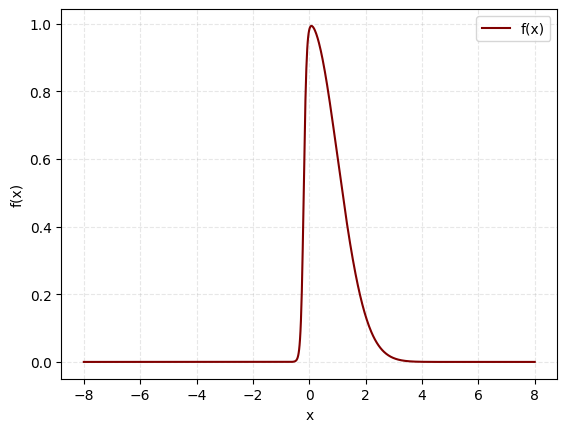

In [64]:
# defining the different functions

# defining the sigmoid function
def sigmoid(x):
    return 1.0 /(1.0 + np.exp(-x))

# defining the unnormalized distribution function
def f(x):
    return sigmoid(20*x + 4) * np.exp(-(x**2)/2)

# defining normal distribution q(x)
def q(x, mu, sigma):
    return (1/np.sqrt(2*np.pi*sigma**2))*np.exp(-0.5*(((x-mu)/sigma)**2))
    

x = np.linspace(-8,8, 1000)
plt.plot(x, f(x), label = "f(x)", color = "maroon")
plt.grid(True, linestyle='--', alpha = 0.3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

### Part 1

Normalization constant =  1.451189367558716
Error =  1.7172205577783506e-08


/tmp/ipykernel_76532/463273241.py:5: RuntimeWarning: overflow encountered in exp
  return 1.0 /(1.0 + np.exp(-x))


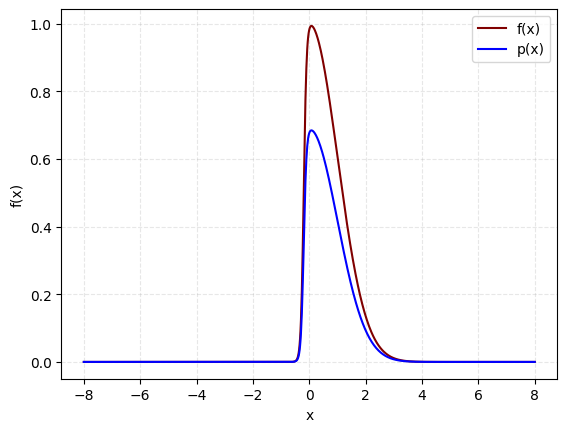

In [65]:
# using Gauss Hermite Quadrature for normalization constant
Z , error = quad(f, -np.inf, np.inf)
print("Normalization constant = ", Z)
print("Error = ", error)

# defining the normalized distribution function
def p(x, Z):
    return f(x)/Z 

plt.plot(x, f(x), label = "f(x)", color = "maroon")
plt.plot(x, p(x,Z), label = "p(x)", color = "blue")
plt.grid(True, linestyle='--', alpha = 0.3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()



### Part 2

mu1 =  [0.07747958]
sigma1 =  [0.62701304]


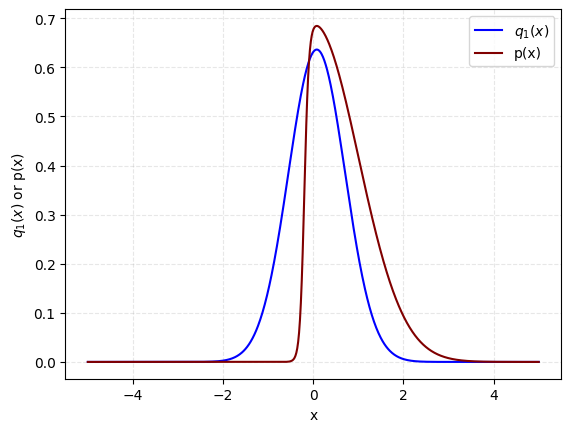

In [100]:
def df(x):
    exp_term = np.exp(-20*x-4)
    return np.exp(-(x**2)/2) * (-2/(1+exp_term) + (20*exp_term/(1+exp_term)**2))

# defining the logf(x) function
def log_f(x):
    return -(x**2)/2 + np.log(sigmoid(20*x + 4))

# defining the first derivative of logf(x) function
def d_logf(x):
    return -x + (20  * np.exp(-20*x - 4) / (1 + np.exp(-20*x - 4))) 

# defining the second derivative of logf(x) function
def d2_logf(x):
    exp_term = np.exp(-20*x - 4)
    return -1 - 400 * exp_term / ( (1 + exp_term)**2 )


# Find the mean
mu1_guess = 2
mu1 = fsolve(d_logf, mu1_guess)

# finding the variance
sigma1_sq_inv = -d2_logf(mu1)
sigma1_sq = 1/(sigma1_sq_inv)
sigma1 = np.sqrt(sigma1_sq)

# printing the calculated mean and variance
print('mu1 = ', mu1)
print('sigma1 = ', sigma1) 

# defining q1(x)
q1 = q(x, mu1, sigma1)

# plotting p(x) and q1(x)
plt.plot(x, q1, color = "blue",label = r"$q_1(x)$")
plt.plot(x, p(x, Z), color = "maroon",label = "p(x)")
plt.xlabel("x")
plt.ylabel(r"$q_1(x)$ or p(x)")
plt.legend()
plt.grid(True, linestyle = "dashed",alpha = 0.3)
plt.show()

### Part 3

In [81]:
# Define the objective function F(μ, σ^2)
def objective(params):
    mu, log_sigma_sq = params
    sigma_sq = np.exp(log_sigma_sq)
    q = norm(loc=mu, scale=np.sqrt(sigma_sq))
    
    def integrand(x):
        return q.pdf(x) * (-log_f(x))
    
    integral, _ = quad(integrand, -10, 10)  # Using a finite range for integration
    
    return integral - 0.5 * np.log(2 * np.pi * np.e * sigma_sq)



In [89]:
# Initial guesses for μ and log(σ^2)
mu_init = 0.5
log_sigma_sq_init = np.log(1)

# Minimize the objective function
result = minimize(objective, [mu_init, log_sigma_sq_init], method='L-BFGS-B')
mu2, log_sigma_sq2 = result.x
sigma2_sq = np.exp(log_sigma_sq2)
sigma2 = np.sqrt(sigma2_sq)

# defining q2(x)
q2 = q(x, mu2, sigma2)


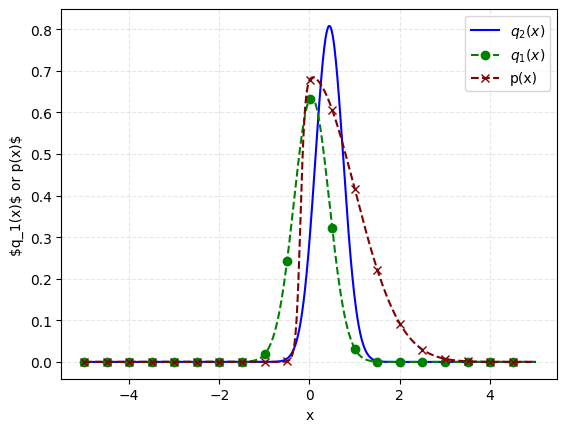

$\mu_2$ = 0.7071
$\sigma_2^2$ = 0.2437


In [98]:
# Plotting
x = np.linspace(-5, 5, 1000)
plt.plot(x, q2, color="blue", label=r"$q_2(x)$")
plt.plot(x, q1, color="green", label=r"$q_1(x)$", linestyle="--", marker='o', markevery=50)
plt.plot(x, p(x, Z), color="maroon", label="p(x)", linestyle="--", marker='x', markevery=50)
plt.xlabel("x")
plt.ylabel(r"$q_1(x)$ or p(x)$")
plt.legend()
plt.grid(True, linestyle="dashed", alpha=0.3)
plt.show()

print(f"$\\mu_2$ = {mu2:.4f}")
print(f"$\\sigma_2^2$ = {sigma2_sq:.4f}")